<div style="text-align: center;"> 
Wave Equation (1D):

$$\frac{\partial^2 u}{\partial t^2} = c^2 \frac{\partial^2 u}{\partial x^2}$$

Central Difference Approximations:

$$\frac{\partial^2 u}{\partial t^2} \approx \frac{u_i^{n+1} - 2u_i^n + u_i^{n-1}}{(\Delta t)^2}$$
$$\frac{\partial^2 u}{\partial x^2} \approx \frac{u_{i+1}^n - 2u_i^n + u_{i-1}^n}{(\Delta x)^2}$$

Forming the System of ODEs:

By discretizing in spatial and temporal dimensions, we replace $\frac{\partial^2 u}{\partial t^2}$ and $\frac{\partial^2 u}{\partial x^2}$ with the central differences:

<!-- $$\frac{d^2 u_i}{dt^2} = \frac{c^2}{(\Delta x)^2} \left( u_{i+1}(t) - 2u_i(t) + u_{i-1}(t) \right)$$

This is rewritten as a first-order system by introducing velocity $v_i = \frac{du_i}{dt}$:

$$\frac{du_i}{dt} = v_i(t)$$
$$\frac{dv_i}{dt} = \frac{c^2}{(\Delta x)^2} \left( u_{i+1}(t) - 2u_i(t) + u_{i-1}(t) \right)$$ -->

$$\frac{u_i^{n+1} - 2u_i^n + u_i^{n-1}}{(\Delta t)^2} = \frac{c^2}{(\Delta x)^2} (u_{i+1}^n - 2u_i^n + u_{i-1}^n)$$


Solving for the Next Time Step:

$$u_i^{n+1} = 2u_i^n - u_i^{n-1} + \underbrace{C^2 \left( u_{i+1}^n - 2u_i^n + u_{i-1}^n \right)}_{\text{Spatial curvature scaled by } C^2}$$

where $C = \frac{c \, \Delta t}{\Delta x}$ is the Courant number.
</div>

* $\frac{\partial^2 u}{\partial t^2}$: acceleration of the displacement — how the wave's velocity itself is changing over time.
* $\frac{\partial^2 u}{\partial x^2}$: spatial curvature — how much a point's displacement differs from its neighbors.
* $u_i^{n+1}$: The displacement at point $i$ at the next time step.
* $u_i^n$: The displacement at point $i$ right now.
* $u_i^{n-1}$: The displacement at point $i$ at the previous time step.

The Stability Criterion (CFL Condition)
For the simulation to remain stable and not "explode" (mathematically diverge), the Courant number must satisfy:

$$С = \frac{c \, \Delta t}{\Delta x} \leq 1$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pulse import get_square_pulse, get_gaussian_pulse

# 1D Wave Equation

In [18]:
N = 100
u = np.zeros(N)

u += get_gaussian_pulse(N, 1)

c = 1.0
dt = 0.1
dx = 1.0

C = c * dt / dx

u_prev = u.copy()

def propagate_t_1D(u):
  global u_prev
  u_next = u.copy()

  for i in range(1, u.shape[0] - 1):
    u_curr_prev = u_prev[i]

    u_next[i] = 2 * u[i] - u_curr_prev + C**2 * (u[i + 1] - 2 * u[i] + u[i - 1])

  u_prev = u.copy()
  u[:] = u_next

curr_t = 0

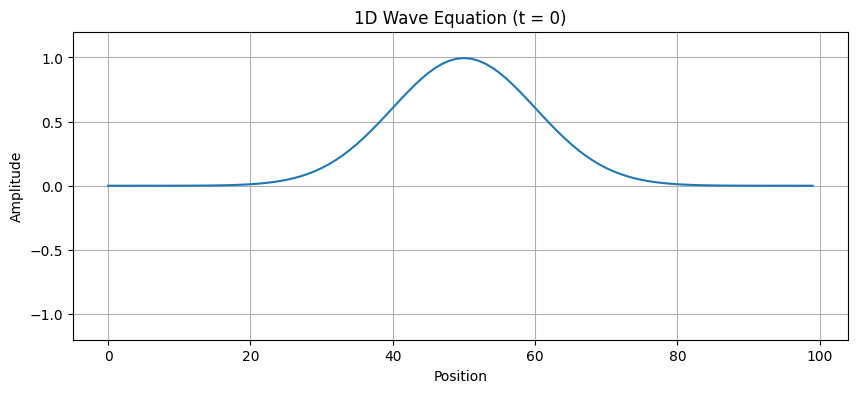

In [20]:
fig, ax = plt.subplots(figsize=(10, 4))
line, = ax.plot(np.arange(N), u)
ax.set_ylim(-1.2, 1.2)
ax.set_xlabel("Position")
ax.set_ylabel("Amplitude")
ax.set_title(f"1D Wave Equation (t = {curr_t})")
ax.grid(True)

for _ in range(10):
  propagate_t_1D(u)

# 2D

$$\frac{\partial^2 u}{\partial t^2} = c^2 \left( \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} \right)$$

$$f(u_{i,j}) = c^2 \left[ \frac{u_{i+1,j} - 2u_{i,j} + u_{i-1,j}}{(\Delta x)^2} + \frac{u_{i,j+1} - 2u_{i,j} + u_{i,j-1}}{(\Delta y)^2} \right]$$

$$u_{i,j}^{n+1} = 2u_{i,j}^{n} - u_{i,j}^{n-1} + (c\,\Delta t)^2 \left[ \frac{u_{i+1,j}^{n} - 2u_{i,j}^{n} + u_{i-1,j}^{n}}{(\Delta x)^2} + \frac{u_{i,j+1}^{n} - 2u_{i,j}^{n} + u_{i,j-1}^{n}}{(\Delta y)^2} \right]$$

Stricter Stability (CFL condition): In 2D, if we assume $\Delta x = \Delta y$, the limit is:$$\frac{c\,\Delta t}{\Delta x} \leq \frac{1}{\sqrt{2}}$$

If $\Delta x = \Delta y = h$, let $C = \frac{c\,\Delta t}{h}$:

$$u_{i,j}^{n+1} = 2u_{i,j}^{n} - u_{i,j}^{n-1} + C^2 \left[ u_{i+1,j}^{n} + u_{i-1,j}^{n} + u_{i,j+1}^{n} + u_{i,j-1}^{n} - 4u_{i,j}^{n} \right]$$

# Laplacian Kernel (to Utilize Convolution Operation)


The discrete Laplacian with $\Delta x = \Delta y = h$ corresponds to convolution with the kernel:

$$L = \begin{bmatrix} 0 & 1 & 0 \\ 1 & -4 & 1 \\ 0 & 1 & 0 \end{bmatrix}$$

$$(L * u)_{i,j} = u_{i+1,j} + u_{i-1,j} + u_{i,j+1} + u_{i,j-1} - 4u_{i,j}$$

So the update becomes a convolution:

$$u^{n+1} = 2u^{n} - u^{n-1} + C^2 (L * u^{n})$$

# CUDA GPU

In [21]:
import torch
import torch.nn as nn

device = torch.device("cuda")

N = 1000

dim = (N, N)
u_gpu = torch.zeros(dim, device=device)

u_gpu += torch.from_numpy(
  get_gaussian_pulse(dim, 1)
).to(device)

u_gpu_prev = torch.zeros((N, N), device=device)

dt = 0.1
dx = 1.0
c = 1.0

C = c * dt / dx

if C > 1 / np.sqrt(2):
  print("Warning: CFL condition violated. The simulation may be unstable.")

kernel_gpu = torch.tensor([
  [0, 1, 0], 
  [1, -4, 1], 
  [0, 1, 0]], 
  dtype=torch.float32, 
  device=device
).view(1, 1, 3, 3)

def GPU_propagate_t_2D(repeats):
  global u_gpu, u_gpu_prev

  for _ in range(repeats):
    u_gpu_next = torch.zeros_like(u_gpu)

    # Convolution to Compute Laplacian
    laplacian = nn.functional.conv2d(
      u_gpu.unsqueeze(0).unsqueeze(0), 
      kernel_gpu, 
      padding=1
    ).squeeze()

    u_gpu_next = 2 * u_gpu - u_gpu_prev + C**2 * laplacian

    u_gpu_prev = u_gpu.clone()
    u_gpu = u_gpu_next.clone()
 

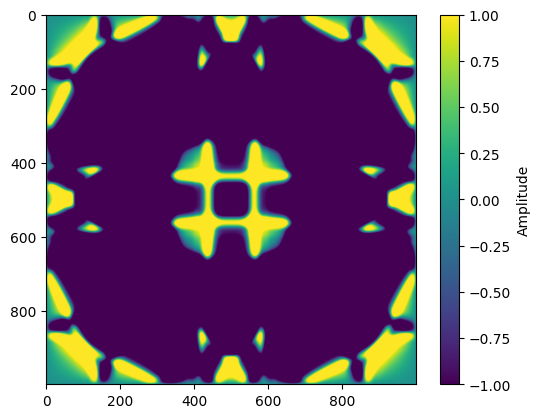

In [87]:
plt.imshow(u_gpu.cpu().numpy(), cmap='viridis', vmin=-1, vmax=1)
plt.colorbar(label='Amplitude')

plt.show()

GPU_propagate_t_2D(1000)